<a href="https://colab.research.google.com/github/PozieSwagger/lis4693/blob/main/Lab-4/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Supervised Machine Learning

In this lab assignment, we will learn to perform supervised machine learning using `sklearn` library. I would highly recommend that you go through its documentation to learn more about performing different types of ML tasks like classification, regression, clustering, model selection and dimensionality reduction here: https://scikit-learn.org/stable/


*Note: Before starting this lab assignment, please complete the Introduction to Machine Learning notebook*

## Leaning Objectives

In this exercise, you will:

- Load and process the assigned data file
- Identify `features` and `target` labels for your dataset
- Split your data into test and training sets
- Perform text-preprocessing
- Compare different classifiers' performances based on their evaluation metrics (accuracy, precision, recall, f1-score) and pick the best one for your dataset
- Visualize the confusion matrix results
- Finally, use the classifier to run on unseen (new) data to make predictions


This exercise builds directly on concepts from discussed in the precursor notebook on "Introduction to Machine Learning".

## Install and Load Libraries

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Load and read your file from GitHub

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/PozieSwagger/lis4693/refs/heads/main/Lab-4/train.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

Let's save it as a DataFrame using `df` variable that holds pandas DataFrame and see how it looks!

As you can see, this dataset consists of metadata for journal articles published in gender and politics related journals.

In [3]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


Now, we will Split our data into **features** and **target** labels.

This dataset was part of one of my research projects, where we added a new column **"code_choice"** and the annotators manually added if the article was related to gender research or not based on the **"abstract"** for those articles.

For this dataset, as I mentioned above our features will be **Abstract** and target will be **code_choices**

In [4]:
features = df['Title']
target = df['Class Index']

Below, I am renaming the `code_choice` as numbers 1 or 0, where 1 states the abstract is related to gender research and 0 means the abstract is not related to gender research.

In [5]:
target_names = {
    'world' : '1',
    'sport' : '2',
    'business' : '3',
    'sci/tech' : '4'
              }

## Splitting Data into Training and Test Sets

Now, we will prepare our data to get ready before feeding it into any machine learning classifiers.

We will first split the data into a test dataset (20%) and a training datset (80%) randomly in 80:20 ratio followed by text-preprocessing.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 96000 samples.
Testing set has 24000 samples.
Preprocessing training data...
Preprocessing test data...


In [8]:
y_test.unique()

array([3, 2, 4, 1])

## Comparing Classifiers

Now, we will run 5 different classifiers (Naive Bayes, Logistic Regression, Support Vector Machine, AdaBoost, Random Forest) on our dataset and see which one performs best based on the evaluation metrics (accuracy, recall, precision, f1 score)

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [13]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [14]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.8617083333333333
SVM Accuracy: 0.870875
LR Accuracy: 0.8635
ADA Accuracy: 0.3612916666666667
RF Accuracy: 0.8062916666666666


The results above indicate that the ADA classifier performed best, achieving an accuracy of 91%. However, accuracy alone should not be the sole criterion for selecting a classifier. Other evaluation metrics, such as precision, recall, and F1-score, should also be considered to obtain a more comprehensive assessment of model performance.

Now, we will run the classification report for all 5 classifiers.

In [15]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, ada_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))


              precision    recall  f1-score   support

       world       0.87      0.87      0.87      5956
       sport       0.90      0.93      0.91      6058
    business       0.83      0.83      0.83      5911
    sci/tech       0.85      0.83      0.84      6075

    accuracy                           0.86     24000
   macro avg       0.86      0.86      0.86     24000
weighted avg       0.86      0.86      0.86     24000

              precision    recall  f1-score   support

       world       0.90      0.85      0.87      5956
       sport       0.87      0.94      0.90      6058
    business       0.83      0.82      0.83      5911
    sci/tech       0.86      0.84      0.85      6075

    accuracy                           0.86     24000
   macro avg       0.86      0.86      0.86     24000
weighted avg       0.86      0.86      0.86     24000

              precision    recall  f1-score   support

       world       0.50      0.32      0.39      5956
       sport       0.

The code from line 51-54 runs the classification report for Support Vactor Machine classifier.

In [16]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [17]:


nt("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [18]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.870875


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

       world       0.89      0.86      0.88      5956
       sport       0.90      0.94      0.92      6058
    business       0.83      0.84      0.83      5911
    sci/tech       0.86      0.85      0.85      6075

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



Again, based on all the classification report for all the evaluation metrics across precision, recall, accuracy, and f1 score, AdaBoost performed the best!

Now, we will visualize the confusion matrix using the AdaBoost classifier.

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'world'),
  Text(1.5, 0, 'sport'),
  Text(2.5, 0, 'business'),
  Text(3.5, 0, 'sci/tech')])

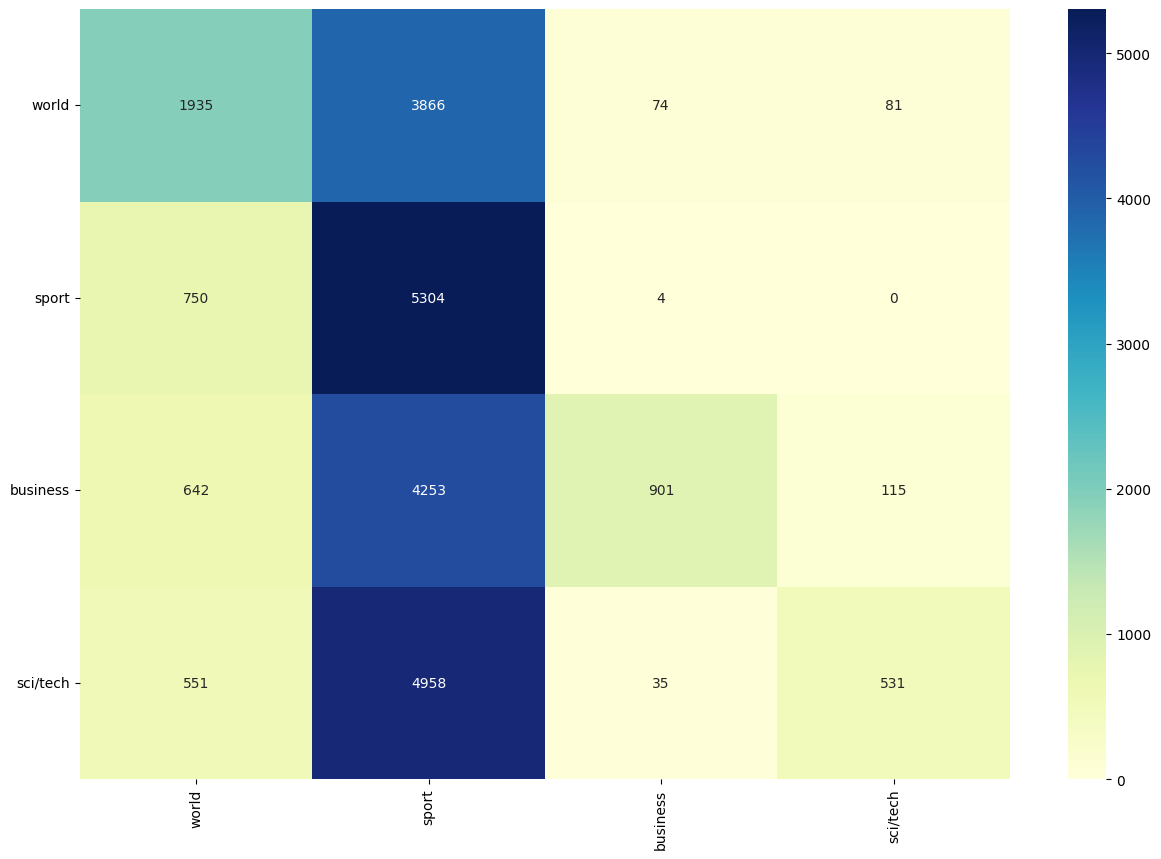

In [25]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, ada_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

The confusion matrix shows the number of abstracts that AdaBoost correctly and incorrectly classified as gendered and non-gendered research. For example, the model correctly classified 302 abstracts as gendered but incorrectly labeled 60 abstracts as gendered when they were actually non-gendered. Similarly, the model correctly classified 600 abstracts as non-gendered, while misclassifying 25 abstracts as non-gendered when they were in fact gendered.

## Supervised Machine Learning

Now, we will use the machine learning model that selected with AdaBoost Classifier to run on the data it has never seen to make predictions aka Supervised Machine Learning!

For this task, we will now upload new dataset with empty "code_choice" column.

In [26]:
url = "https://raw.githubusercontent.com/PozieSwagger/lis4693/refs/heads/main/Lab-4/train.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


In [27]:
text = new_data['Title']

In [28]:
text

,Title
0,Wall St. Bears Claw Back Into the Black (Reuters)
1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters)
3,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new..."
...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...
119996,Renteria signing a top-shelf deal
119997,Saban not going to Dolphins yet
119998,Today's NFL games


Now, we will do text-preprocessing.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [30]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

## Predicting Features: Fitting New Dataset

Using the code below, we will use the AdaBoost Classifier to make predictions based on our previously trained machine learning model.

Here the `fit()` method trains the AdaBoost Classifier model using our training data:

- `dtm` represents the preprocessed training features. It's likely a Document-Term Matrix (DTM) or TF-IDF matrix generated from the text abstracts (X_train) during the text preprocessing steps.
- `y_train` is the corresponding target labels (e.g., 0 or 1 for 'non-gendered' or 'gendered' research) for each sample in dtm.

After this line executes, classifier holds the trained machine learning model, ready to make predictions.

In [31]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
classif = model.fit(dtm, y_train)

The next line of code preprocesses the 'Abstract' column (AB) from the `new_data` DataFrame so that it's in the same format as the data the model was trained on.

In [32]:
test_dtm = vect.transform(new_data['Title'])

Removing any empty values for abstracts

In [33]:
import pandas as pd

# Replace NaN values with an empty string before applying transform
new_data['Title'] = new_data['Title'].fillna('')
test_dtm = vect.transform(new_data['Title'])

Using the code below, we are making predictions using our machine learning model for the `code_choice` in our new dataset.

In [34]:
test = classif.predict(test_dtm)

Here, I am renaming the column from 0 -> code_choice.

In [35]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'Class Index'}, inplace=True)

In [36]:
df2

,Class Index
0,3
1,3
2,3
3,1
4,3
...,...
119995,3
119996,3
119997,3
119998,3


You can see from above results that we have now successfully tagged each article based on the abstract as 1 (gendered) or 0 (non-gendered)!!

Let’s merge the metadata from the new_data file with the `code_choice` column from df2 into the original file that contains the empty column. This will allow us to reconstruct the complete dataset, which can then be shared with others or used for downstream analysis and processing.

In [37]:
new_data['Class Index'] = df2['Class Index']
combined_df = new_data

In [38]:
display(combined_df.head())

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,1,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Let's SAVE the combined data as a CSV file.

In [39]:
combined_df.to_csv('predicted_data.csv', index=False)

# Reflection

##Q1
Running the code was simple and easy to trace an understand.

##Q2
Issues that were pevelent is the time that train took to finish. Most of the code ran completely fine but how long some fuctions took to complete would have reach 20-30 min to complete.